# Сборный проект. Исследование интернет-магазина компьютерных игр «Стримчик».

Предоставлены из открытых источников исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы интернет-магазина  «Стримчик».


***Цель:***
выявить закономерности успешных игр, чтобы определелить потенциально популярные продукты в этом сигменте для прогнозирования продаж на 2017 год

***План работ:***

**Шаг 1. Загрузка данных** \
Загрузить данные и изучить общую информацию о полученном датафрейме

**Шаг 2. Предобработка данных** \
2.1 Заменить названия столбцов. Преобразовать данные в нужные типы. Описать, в каких столбцах заменили тип данных и почему.
Обработать пропуски при необходимости: 
- Объяснить, почему заполнили пропуски определённым образом или почему не стали это делать;
- Описать причины, которые могли привести к пропускам;
- Обратить внимание на аббревиатуру 'tbd' в столбце с оценкой пользователей. Отдельно разобрать это значение и описать, как его обработать;
  
2.2 Посчитать суммарные продажи во всех регионах и записать их в отдельный столбец
 
**Шаг 3. Провести исследовательский анализ данных** \
3.1 Посмотреть, сколько игр выпускалось в разные годы. Важны ли данные за все периоды \
3.2 Посмотреть, как менялись продажи по платформам. Выбрать платформы с наибольшими суммарными продажами и построить распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы. Определить актуальный период \
3.3 Какие платформы лидируют по продажам, растут или падают? Выбрать несколько потенциально прибыльных платформ \
3.4 Построить график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Описать результ \
3.5 Посмотреть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построить диаграмму рассеяния и посчитать корреляцию между отзывами и продажами. Сформулировать выводы \
3.6 Соотнести выводы с продажами игр на других платформах \
3.7 Посмотреть на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами?

**Шаг 4. Составить портрет пользователя каждого региона** \
4.1 Определить для пользователя каждого региона (NA, EU, JP) самые популярные платформы (топ-5). Описать различия в долях продаж \
4.2 Определить для пользователя каждого региона (NA, EU, JP) самые популярные жанры (топ-5). Пояснить разницу \
4.3 Определить для пользователя каждого региона (NA, EU, JP) влияет ли рейтинг ESRB на продажи в отдельном регионе

**Шаг 5. Проверть гипотезы** \
Задать самостоятельно пороговое значение alpha. Пояснить:
- как вы сформулировали нулевую и альтернативную гипотезы 
- какой критерий применили для проверки гипотез и почему 
5.1 средние пользовательские рейтинги платформ Xbox One и PC одинаковые \
5.2 средние пользовательские рейтинги жанров Action и Sports разные 

**Шаг 6. Написать общий вывод** 


## Шаг 1. Загрузка данных

In [1]:
import pandas as pd # импортирт библиотеки pandas
import matplotlib.pyplot as plt
import numpy as np
from math import sqrt, factorial
from scipy import stats as st
from scipy.stats import binom, poisson, norm

In [2]:
# отображение всех колонок при выводе на печать
pd.set_option('display.max_columns', None)

In [3]:
games=pd.read_csv('/datasets/games.csv', sep=',') # прочла csv-файл о пользователях
display(games.head(10))
display(games.info())
display(games.describe())

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN
5,Tetris,GB,1989.0,Puzzle,23.20,2.26,4.22,0.58,NaN,NaN,NaN
6,New Super Mario Bros.,DS,2006.0,Platform,11.28,9.14,6.50,2.88,89.0,8.5,E
7,Wii Play,Wii,2006.0,Misc,13.96,9.18,2.93,2.84,58.0,6.6,E
8,New Super Mario Bros. Wii,Wii,2009.0,Platform,14.44,6.94,4.70,2.24,87.0,8.4,E
9,Duck Hunt,NES,1984.0,Shooter,26.93,0.63,0.28,0.47,NaN,NaN,NaN


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


None

,Year_of_Release,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score
count,16446.000000,16715.000000,16715.000000,16715.000000,16715.000000,8137.000000
mean,2006.484616,0.263377,0.145060,0.077617,0.047342,68.967679
std,5.877050,0.813604,0.503339,0.308853,0.186731,13.938165
min,1980.000000,0.000000,0.000000,0.000000,0.000000,13.000000
25%,2003.000000,0.000000,0.000000,0.000000,0.000000,60.000000
50%,2007.000000,0.080000,0.020000,0.000000,0.010000,71.000000
75%,2010.000000,0.240000,0.110000,0.040000,0.030000,79.000000
max,2016.000000,41.360000,28.960000,10.220000,10.570000,98.000000


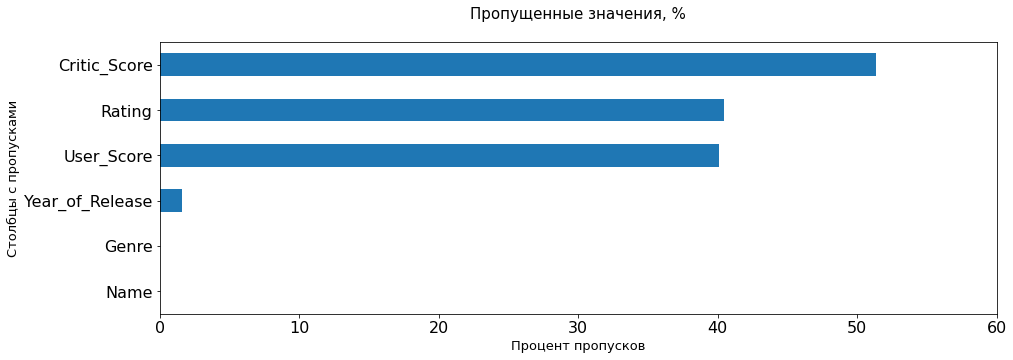

In [4]:
def pass_value(games):
    try:
        (
            (games.isna().mean()*100)
            .to_frame()
            .rename(columns = {0:'space'})
            .query('space > 0')
            .sort_values(by = 'space', ascending = True)
            .plot(kind = 'barh', figsize = (15,5), rot = 0, legend = False, fontsize = 16)           
        ); 
        plt.title('Пропущенные значения, %' + "\n", fontsize=15)
        plt.xlabel('Процент пропусков', fontsize=13)
        plt.ylabel('Столбцы с пропусками', fontsize=13)  
        plt.xlim(0, 60) 
    except:
        print('пропусков не осталось :) или произошла ошибка в первой части функции ')
        
pass_value(games)

Столбцы 'Name' и 'Genre' имею меньше 1% пропусков. Их можно будет удалить. 

In [5]:
pass_values = games.isnull().sum() #кол-во пропущенных значений в столбцах
total_pass = pass_values.sum() #кол-во пропущенных значений во всем датасете 
total_cells = games.size #кол-во ячеек во всем датасете 
pass_ratio = total_pass / total_cells 
print('Процент пропусков во всем датасете {:.2%}'.format(pass_ratio))

Процент пропусков во всем датасете 12.14%


***Вывод:***
В датасете 16715 строк и 11 столбцов. Пропуски составляют 12 % от всего датасете, также имеется некорректный тип данных некоторых столбцов. Нарушены правила стиля в названии столбцов, а именно, использование верхнего регистра.

## Шаг 2. Предобработка данных

### Заменить названия столбцов. Преобразовать данные в нужные типы. Описать, в каких столбцах заменили тип данных и почему. Обработать пропуски при необходимости

In [6]:
games.rename(columns=str.lower, inplace=True) # преобразование имен всех столбцов в нижний регистр
list(games.columns.values)

['name',
 'platform',
 'year_of_release',
 'genre',
 'na_sales',
 'eu_sales',
 'jp_sales',
 'other_sales',
 'critic_score',
 'user_score',
 'rating']

In [7]:
games.columns = games.columns.str.lower()
games.columns

Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')

In [8]:
print(games.isna().sum()) # количество пропущенных значений для каждого столбца 
print(games.duplicated().sum()) # число дубликатов 
games.shape

name                  2
platform              0
year_of_release     269
genre                 2
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8578
user_score         6701
rating             6766
dtype: int64
0


(16715, 11)

In [9]:
# дубликаты по части значений
games[games.duplicated(subset=['name', 'platform', 'year_of_release'], keep=False)] 

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
604,Madden NFL 13,PS3,2012.0,Sports,2.11,0.22,0.00,0.23,83.0,5.5,E
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.00,0.08,NaN,NaN,NaN
14244,NaN,GEN,1993.0,NaN,0.00,0.00,0.03,0.00,NaN,NaN,NaN
16230,Madden NFL 13,PS3,2012.0,Sports,0.00,0.01,0.00,0.00,83.0,5.5,E


In [10]:
games=games.drop_duplicates(['name', 'platform', 'year_of_release']) # удаление будликатов

In [11]:
games.shape

(16713, 11)

In [12]:
# дубликаты по части значений
games[games.duplicated(subset=['name', 'platform'], keep=False)] 

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
1190,Need for Speed: Most Wanted,X360,2012.0,Racing,0.62,0.78,0.01,0.15,83.0,8.5,T
1591,Need for Speed: Most Wanted,X360,2005.0,Racing,1.00,0.13,0.02,0.10,83.0,8.5,T
1745,Sonic the Hedgehog,PS3,2006.0,Platform,0.41,0.06,0.04,0.66,43.0,4.1,E10+
4127,Sonic the Hedgehog,PS3,NaN,Platform,0.00,0.48,0.00,0.00,43.0,4.1,E10+
5972,Need for Speed: Most Wanted,PC,2005.0,Racing,0.02,0.23,0.00,0.04,82.0,8.5,T
11715,Need for Speed: Most Wanted,PC,2012.0,Racing,0.00,0.06,0.00,0.02,82.0,8.5,T


In [13]:
share_name = (games['name'].isna().sum()/ len(games))
print('Процент пропусков в столбце name выпуска {:.2%}'.format(share_name))

share_genre = (games['genre'].isna().sum()/ len(games))
print('Процент пропусков в столбце genre выпуска {:.2%}'.format(share_genre))

Процент пропусков в столбце name выпуска 0.01%
Процент пропусков в столбце genre выпуска 0.01%


In [14]:
# поиск строк с пропусками в 'name'
games[games['name'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
659,NaN,GEN,1993.0,NaN,1.78,0.53,0.0,0.08,NaN,NaN,NaN


In [15]:
games.dropna(subset=['name', 'genre'], inplace=True) # удаление малозначительных пропусков
print(games['name'].isna().sum())
games['genre'].isna().sum()
games.shape

0


(16712, 11)

Пропуски в столбацах 'name' и 'genre' меньше 0.02% (1 строка), следовательно их удалили.

In [16]:
share_year = (games['year_of_release'].isna().sum()/ len(games))
print('Процент пропусков в столбце year_of_release выпуска {:.2%}'.format(share_year))

Процент пропусков в столбце year_of_release выпуска 1.61%


In [17]:
# поиск строк с пропусками в 'year_of_release'
games[games['year_of_release'].isna()]

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
183,Madden NFL 2004,PS2,NaN,Sports,4.26,0.26,0.01,0.71,94.0,8.5,E
377,FIFA Soccer 2004,PS2,NaN,Sports,0.59,2.36,0.04,0.51,84.0,6.4,E
456,LEGO Batman: The Videogame,Wii,NaN,Action,1.80,0.97,0.00,0.29,74.0,7.9,E10+
475,wwe Smackdown vs. Raw 2006,PS2,NaN,Fighting,1.57,1.02,0.00,0.41,NaN,NaN,NaN
609,Space Invaders,2600,NaN,Shooter,2.36,0.14,0.00,0.03,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
16373,PDC World Championship Darts 2008,PSP,NaN,Sports,0.01,0.00,0.00,0.00,43.0,tbd,E10+
16405,Freaky Flyers,GC,NaN,Racing,0.01,0.00,0.00,0.00,69.0,6.5,T
16448,Inversion,PC,NaN,Shooter,0.01,0.00,0.00,0.00,59.0,6.7,M
16458,Hakuouki: Shinsengumi Kitan,PS3,NaN,Adventure,0.01,0.00,0.00,0.00,NaN,NaN,NaN


In [18]:
games = games.dropna(subset=['year_of_release'])
games.shape

(16443, 11)

Пропуски в столбце 'year_of_release' составляют только 1.6 % А также изменим тип данных на целочисленный для удобства работы с датой года.

In [19]:
games['year_of_release'].sort_values().unique()

array([1980., 1981., 1982., 1983., 1984., 1985., 1986., 1987., 1988.,
       1989., 1990., 1991., 1992., 1993., 1994., 1995., 1996., 1997.,
       1998., 1999., 2000., 2001., 2002., 2003., 2004., 2005., 2006.,
       2007., 2008., 2009., 2010., 2011., 2012., 2013., 2014., 2015.,
       2016.])

In [20]:
# изменен тип данных на int 
games['year_of_release']=games['year_of_release'].astype('int')

In [21]:
games['critic_score'].sort_values().unique()

array([13., 17., 19., 20., 21., 23., 24., 25., 26., 27., 28., 29., 30.,
       31., 32., 33., 34., 35., 36., 37., 38., 39., 40., 41., 42., 43.,
       44., 45., 46., 47., 48., 49., 50., 51., 52., 53., 54., 55., 56.,
       57., 58., 59., 60., 61., 62., 63., 64., 65., 66., 67., 68., 69.,
       70., 71., 72., 73., 74., 75., 76., 77., 78., 79., 80., 81., 82.,
       83., 84., 85., 86., 87., 88., 89., 90., 91., 92., 93., 94., 95.,
       96., 97., 98., nan])

Оценки целые, поэтому переведем тип данных в целочисленный. Заполнить средним по названию игры не получится, так как на разных платформах разные оценки. Заменим пропуски на 110 - больше максимальной оценки.

In [22]:
# изменен тип данных на int и замена пропусков на '110'
games['critic_score']=games['critic_score'].fillna(110).astype('int')

In [23]:
games['user_score'].sort_values().unique()

array(['0', '0.2', '0.3', '0.5', '0.6', '0.7', '0.9', '1', '1.1', '1.2',
       '1.3', '1.4', '1.5', '1.6', '1.7', '1.8', '1.9', '2', '2.1', '2.2',
       '2.3', '2.4', '2.5', '2.6', '2.7', '2.8', '2.9', '3', '3.1', '3.2',
       '3.3', '3.4', '3.5', '3.6', '3.7', '3.8', '3.9', '4', '4.1', '4.2',
       '4.3', '4.4', '4.5', '4.6', '4.7', '4.8', '4.9', '5', '5.1', '5.2',
       '5.3', '5.4', '5.5', '5.6', '5.7', '5.8', '5.9', '6', '6.1', '6.2',
       '6.3', '6.4', '6.5', '6.6', '6.7', '6.8', '6.9', '7', '7.1', '7.2',
       '7.3', '7.4', '7.5', '7.6', '7.7', '7.8', '7.9', '8', '8.1', '8.2',
       '8.3', '8.4', '8.5', '8.6', '8.7', '8.8', '8.9', '9', '9.1', '9.2',
       '9.3', '9.4', '9.5', '9.6', '9.7', 'tbd', nan], dtype=object)

В 'user_score' есть пропуски и оценка - 'tbd'. Заменим пропуски на 11 - больше максимальной оценки.

In [24]:
# замена пропусков на '11' - больше максимальной оценки
games['user_score']=games['user_score'].fillna(11)

In [25]:
# вывод строк с оценкой 'tbd'
games[games['user_score'] == 'tbd']

,name,platform,year_of_release,genre,na_sales,eu_sales,jp_sales,other_sales,critic_score,user_score,rating
119,Zumba Fitness,Wii,2010,Sports,3.45,2.59,0.0,0.66,110,tbd,E
301,Namco Museum: 50th Anniversary,PS2,2005,Misc,2.08,1.35,0.0,0.54,61,tbd,E10+
520,Zumba Fitness 2,Wii,2011,Sports,1.51,1.03,0.0,0.27,110,tbd,T
645,uDraw Studio,Wii,2010,Misc,1.65,0.57,0.0,0.20,71,tbd,E
718,Just Dance Kids,Wii,2010,Misc,1.52,0.54,0.0,0.18,110,tbd,E
...,...,...,...,...,...,...,...,...,...,...,...
16695,Planet Monsters,GBA,2001,Action,0.01,0.00,0.0,0.00,67,tbd,E
16697,Bust-A-Move 3000,GC,2003,Puzzle,0.01,0.00,0.0,0.00,53,tbd,E
16698,Mega Brain Boost,DS,2008,Puzzle,0.01,0.00,0.0,0.00,48,tbd,E
16704,Plushees,DS,2008,Simulation,0.01,0.00,0.0,0.00,110,tbd,E


TBD - аббревиатура от английского To Be Determined (будет определено) или To Be Decided (будет решено). Используется, если какая-то информация еще не определена или решение по вопросу не принято. Следовательно, 'tbd' это еще неизестные оценки. Заменим их на то же самое значение, что и пропуски, чтобы можно было работать с числовыми таблицами. 

In [26]:
# заменили 'tbd' на оценку '11', как и пропуски
games.loc[games['user_score'] == 'tbd', 'user_score'] = 11
games['user_score']=games['user_score'].astype('float')

Тип данный изменила на float для работы с числами.

In [27]:
games['rating'].sort_values().unique()

array(['AO', 'E', 'E10+', 'EC', 'K-A', 'M', 'RP', 'T', nan], dtype=object)

Разберемся в аббревиатуре рейтинга от организации ESRB: 

- AO — «Adults Only 18+» — «Только для взрослых от 18 лет»
- E — «Everyone» — «Для всех от 6 лет»
- E10+ — «Everyone 10 and older» — «Для всех от 10 лет и старше»
- EC — «Early childhood» — «Для детей младшего возраста от 3 лет»
- K-A — «Kids to Adults» — «Для всех» (тоже что и E, использовался до 1998)
- M — «Mature» — «Для взрослых от 17»
- RP — «Rating Pending» — «Рейтинг ожидается»
- T — «Teen» — «Подросткам от 13»

In [28]:
games['rating'] = games['rating'].fillna('unknown')

***Вывод:*** \
Преобразовали имена всех столбцов к нижнему регистру. Удалены дубликаты. Пропуски в столбцах 'year_of_release', 'name' и 'genre' меньше 2 %, следовательно, эти пропуски удалили. Пропуски 'critic_score' и 'user_score' заменили на значения выше максимальных для последующей работы с данными. Расшифрована оценка пользователей 'tbd' как неизвестная оценка, следовательно, заменили ее аналогичной максимальной оценкой. Изменили типы данных у столбцов 'year_of_release' и 'critic_score' на 'int', у 'user_score' на 'float' для работы с числовыми данными.
Пропуски могли появиться из-за несогласованности данных при сборе из различных открытих источников и дальнейшей выгрузки.

### Посчитать суммарные продажи во всех регионах и записать их в отдельный столбец

In [29]:
games['total_sales'] = games['na_sales']+games['eu_sales']+games['jp_sales']+games['other_sales']
games['total_sales'].head()

0    82.54
1    40.24
2    35.52
3    32.77
4    31.38
Name: total_sales, dtype: float64

In [30]:
# проверка на пропуски и на корректность типа данных
display(games.isna().sum())
display(games.info())
games.duplicated().sum() # число дубликатов 

name               0
platform           0
year_of_release    0
genre              0
na_sales           0
eu_sales           0
jp_sales           0
other_sales        0
critic_score       0
user_score         0
rating             0
total_sales        0
dtype: int64

<class 'pandas.core.frame.DataFrame'>
Int64Index: 16443 entries, 0 to 16714
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   name             16443 non-null  object 
 1   platform         16443 non-null  object 
 2   year_of_release  16443 non-null  int64  
 3   genre            16443 non-null  object 
 4   na_sales         16443 non-null  float64
 5   eu_sales         16443 non-null  float64
 6   jp_sales         16443 non-null  float64
 7   other_sales      16443 non-null  float64
 8   critic_score     16443 non-null  int64  
 9   user_score       16443 non-null  float64
 10  rating           16443 non-null  object 
 11  total_sales      16443 non-null  float64
dtypes: float64(6), int64(2), object(4)
memory usage: 1.6+ MB


None

0

***Вывод:*** \
Добавлен столбец 'total_sales' суммарных продаж по всем регионам. Выполнена проверка на корректность типов данных и отстутствие дубликатов и пропусков. 

## Шаг 3. Исследовательский анализ данных

### Посмотреть, сколько игр выпускалось в разные годы. Важны ли данные за все периоды

In [31]:
games['year_of_release'].describe() # описательная статистика года выпуска

count    16443.000000
mean      2006.485921
std          5.875546
min       1980.000000
25%       2003.000000
50%       2007.000000
75%       2010.000000
max       2016.000000
Name: year_of_release, dtype: float64

Данные с 1980 по 2016 год.

Text(0.5, 1.0, 'Диаграмма размаха года выпуска')

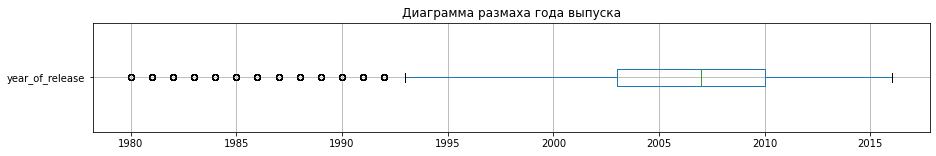

In [32]:
fig, ax = plt.subplots(figsize = (15,2))
ax = games[['year_of_release']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха года выпуска')


Выбросы наблюдаются до 1993 года.

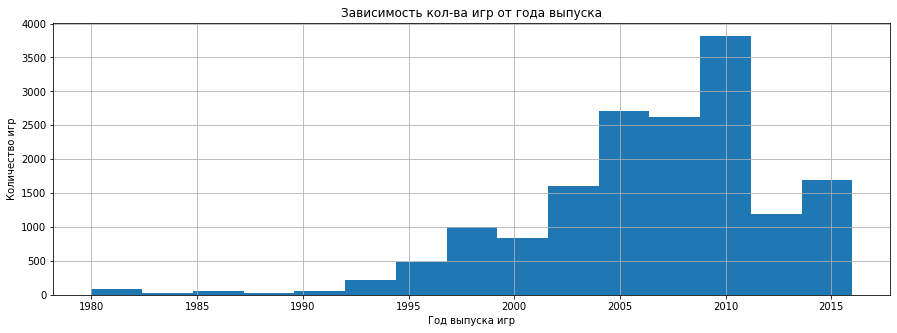

In [33]:
games['year_of_release'].plot(kind='hist', bins=15, grid=True, figsize = (15, 5), range=(1980, 2016)) 
plt.ylabel('Количество игр')
plt.xlabel('Год выпуска игр')
plt.title('Зависимость кол-ва игр от года выпуска');

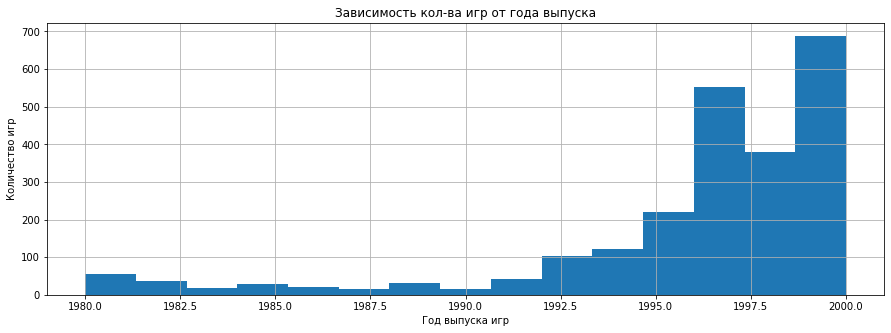

In [34]:
games['year_of_release'].plot(kind='hist', bins=15, grid=True, figsize = (15, 5), range=(1980, 2000)) 
plt.ylabel('Количество игр')
plt.xlabel('Год выпуска игр')
plt.title('Зависимость кол-ва игр от года выпуска');

Незначительное кол-во игр выпускалось до 1992 года, поэтому будем рассматривать период с 1992 года.

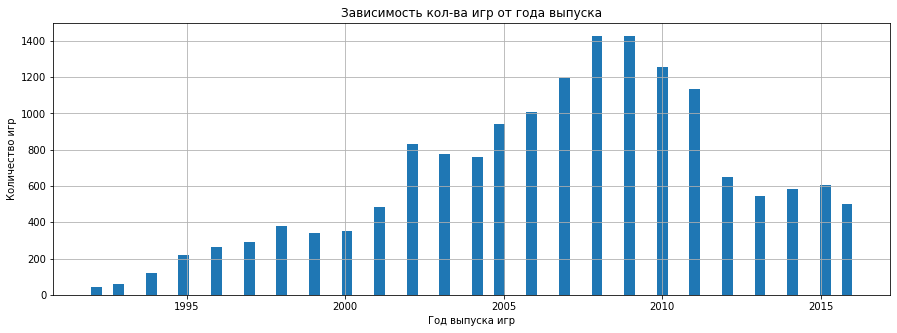

In [35]:
#срез данных без аномалий
good_games = games.query('year_of_release >= 1992')
good_games ['year_of_release'].plot(kind='hist', bins=70, grid=True, figsize = (15, 5)) 
plt.ylabel('Количество игр')
plt.xlabel('Год выпуска игр')
plt.title('Зависимость кол-ва игр от года выпуска');

***Вывод:***
Предоставлены данные за 1980-2016 года. Данные до 1992 малоинформативны, поэтому изучаем период 1992-2016 включительно. Наблюдается рост выпуска игр до 2009 года, далее кол-во выпуска игр падает, резкое снижение в 2012 году и далее более менее рынок стабилен - выпускает около 600 игр в год. Больше всего игр выпускалось в 2008 и 2009 году.

### Посмотреть, как менялись продажи по платформам. Выбрать платформы с наибольшими суммарными продажами и построить распределение по годам. За какой характерный срок появляются новые и исчезают старые платформы. Определить актуальный период 

          total_sales
platform             
PS2           1233.56
X360           961.24
PS3            931.33
Wii            891.18
DS             802.76
PS             727.58
PS4            314.14
GBA            312.88
PSP            289.53
3DS            257.81
PC             255.69
XB             251.57
N64            218.01
GC             196.73
GB             177.57
XOne           159.32
SNES           157.67
WiiU            82.19
PSV             53.81
SAT             33.59
GEN             21.42
DC              15.95
NES              5.70
SCD              1.86
NG               1.44
WS               1.42
TG16             0.16
3DO              0.10
GG               0.04
PCFX             0.03


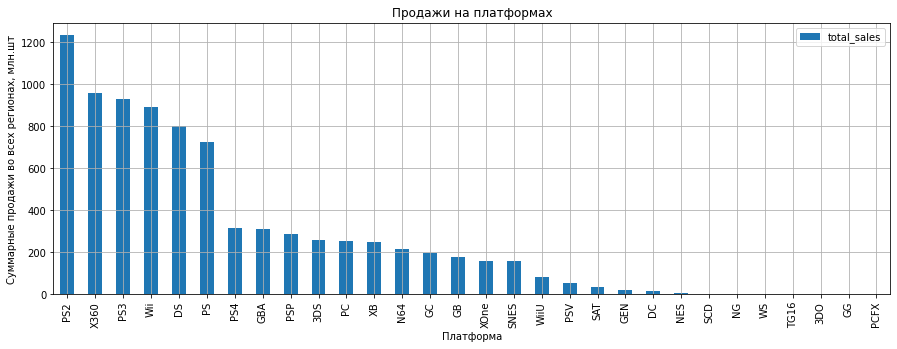

In [36]:
sales_platform = good_games.pivot_table(index='platform', values='total_sales', aggfunc='sum') \
    .sort_values(by='total_sales', ascending=False)
print(sales_platform)
sales_platform.plot(kind='bar', grid=True, figsize=(15, 5))
plt.ylabel('Суммарные продажи во всех регионах, млн.шт')
plt.xlabel('Платформа')
plt.title('Продажи на платформах');

Выделяются 6 платформ.

In [37]:
max_sales_platform = good_games.pivot_table(index='platform', values='total_sales', aggfunc='sum') \
    .sort_values(by='total_sales', ascending=False).reset_index().head(6)['platform'].tolist()
max_sales_platform

['PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS']

In [38]:
result = good_games.query('platform in @max_sales_platform')

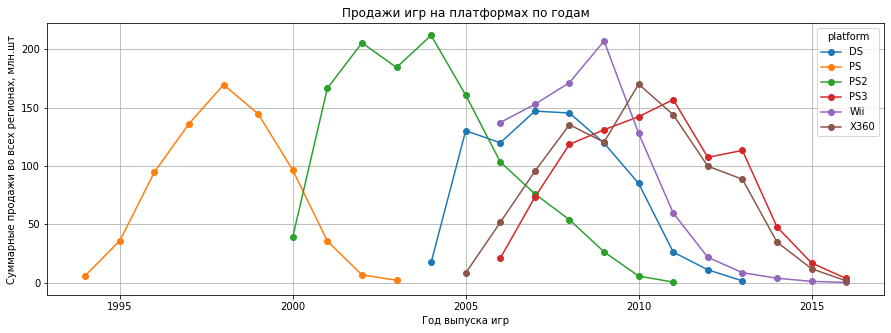

In [39]:
# продажи игр на платформах с наибольшими суммарными продажами по годам
max_sales_platform_year = result.pivot_table(index=['year_of_release'], values='total_sales', columns='platform', aggfunc='sum') \
    .sort_values(by='year_of_release').plot(kind='line', style='-o', grid=True, figsize=(15, 5))
plt.ylabel('Суммарные продажи во всех регионах, млн.шт')
plt.xlabel('Год выпуска игр')
plt.title('Продажи игр на платформах по годам');

Каждая платформа набирает максимальное число продаж в течение 3-5 лет - в среднем за 4 года платформа достигает пика.

In [40]:
# рассчет медианного значения срока жизни платформ по датасету good_games - за 25 лет
time_life = good_games.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']).reset_index()
# последний год включительно, поэтому +1
time_life['time_life']= time_life['max'] - time_life['min'] + 1 
print(time_life.sort_values(by='time_life'))
print('Медианное значение срока жизни платформы', time_life['time_life'].median())

   platform             min             max time_life
            year_of_release year_of_release          
23     TG16            1995            1995         1
13     PCFX            1996            1996         1
8        GG            1992            1992         1
0       3DO            1994            1995         2
21      SCD            1993            1994         2
24       WS            1999            2001         3
7       GEN            1992            1994         3
10      NES            1992            1994         3
17      PS4            2013            2016         4
11       NG            1993            1996         4
29     XOne            2013            2016         4
26     WiiU            2012            2016         5
20      SAT            1994            1999         6
1       3DS            2011            2016         6
19      PSV            2011            2016         6
9       N64            1996            2002         7
6        GC            2001 

In [41]:
# рассчет медианного значения срока жизни пплатформ по выборке с наибольшими суммарными продажами - за 23 года
time_life_max_sales_platform = result.pivot_table(index='platform', values='year_of_release', aggfunc=['min', 'max']) \
    .reset_index()
time_life_max_sales_platform['time_life']= time_life_max_sales_platform['max'] - time_life_max_sales_platform['min'] +1
print(time_life_max_sales_platform.sort_values(by='time_life'))
print('Медианное значение срока жизни платформы', time_life_max_sales_platform['time_life'].median())

  platform             min             max time_life
           year_of_release year_of_release          
0       DS            2004            2013        10
1       PS            1994            2003        10
3      PS3            2006            2016        11
4      Wii            2006            2016        11
2      PS2            2000            2011        12
5     X360            2005            2016        12
Медианное значение срока жизни платформы 11.0


***Вывод:*** \
За 25 лет (выборка 1994 - 2016 года) выделены 6 лидирующих по продажам платформ - 'PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS'. Самая продаваемая платформа - PS2. Данные платформы существуют от 10 до 12 лет, а медианное значение срока жизни платформы - 11 лет. 
На графике наблюдается тенденция - каждая платформа набирает максимальное число продаж в течение 3-5 лет, в среднем получаем 4 года, следовательно, актуальный период с 2013 по 2016 включительно.

### Какие платформы лидируют по продажам, растут или падают? Выбрать несколько потенциально прибыльных платформ 

In [42]:
current_time = good_games.query('year_of_release >= 2013')

In [43]:
sales_platform = current_time.pivot_table(index='platform', values='total_sales', aggfunc='sum') \
    .sort_values(by='total_sales', ascending=False)
sales_platform

,total_sales
platform,
PS4,314.14
PS3,181.43
XOne,159.32
3DS,143.25
X360,136.80
WiiU,64.63
PC,39.43
PSV,32.99
Wii,13.66


За данный актуальный период по продажам лидирует платформа PS4 - 314 млн копий.

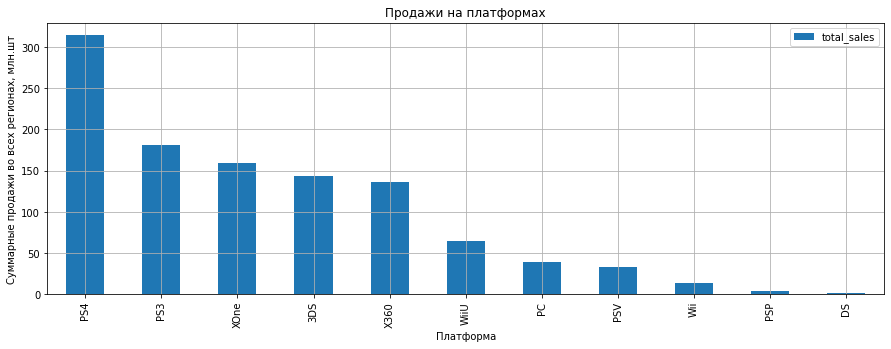

In [44]:
sales_platform.plot(kind='bar', grid=True, figsize=(15, 5))
plt.ylabel('Суммарные продажи во всех регионах, млн.шт')
plt.xlabel('Платформа')
plt.title('Продажи на платформах');

Последнии 2 платформы - PSP и DS - малоинформативны, их можно удалить из выборки. 

In [45]:
current_time = good_games.query('year_of_release >= 2013 and platform != "PSP" and platform != "DS"')

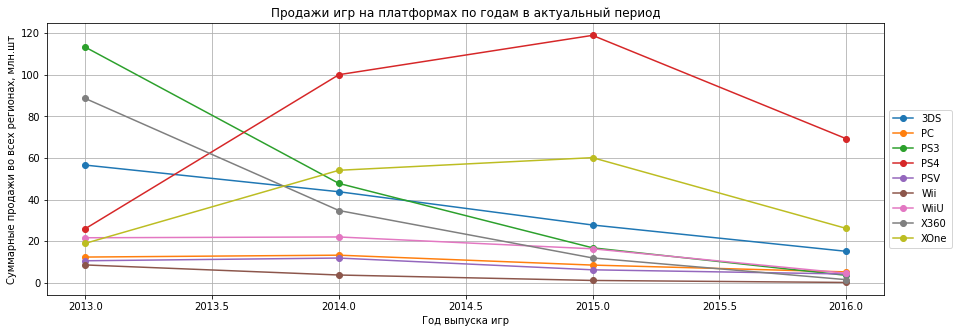

In [46]:
sales_platform_year_current_time = current_time.pivot_table(index=['year_of_release'], values='total_sales', \
                                                            columns='platform', aggfunc='sum').sort_values(by='year_of_release')
sales_platform_year_current_time.plot(kind='line', style='-o', grid=True, figsize=(15, 5))
plt.ylabel('Суммарные продажи во всех регионах, млн.шт')
plt.xlabel('Год выпуска игр')
plt.title('Продажи игр на платформах по годам в актуальный период')
plt.legend(bbox_to_anchor=(1, 0.7));

***Вывод:***
В актуальный период попало 11 платформ. По продажам лидируют 5 платформа - PS4, PS3, XOne, 3DS, X360 - около 1 млд копий. \
У платформ PS4, XOne наблюдается увеличение продаж с последующим уменьшением. Остальные платформы на стадии падения - PS3, 3DS, WiiU, X360, PC, Wii, PSV, DS, PSP. \
Также следует отметить 2 платформы, завершающие свой срок жизни в данный перод - DS, PSP малоинформативны, поэтому их удалили из выборки. А 2 платформы, начинающие срок жизни в 2013 году - PS4 и XOne, - потенциально прибыльные платформы. 

### Построить график «ящик с усами» по глобальным продажам игр в разбивке по платформам. Описать результ

In [47]:
current_time['total_sales'].describe() # описательная статистика продаж игр

count    2158.000000
mean        0.503082
std         1.253867
min         0.010000
25%         0.040000
50%         0.120000
75%         0.420000
max        21.050000
Name: total_sales, dtype: float64

Значения медианы и среднего отличаюся - есть выбросы, влияющие на данные

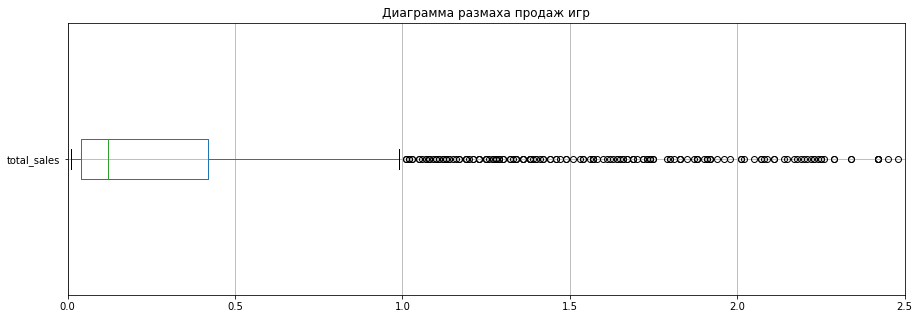

In [48]:
fig, ax = plt.subplots(figsize = (15,5))
ax = current_time[['total_sales']].boxplot(vert = False, ax =ax)
ax.set_title('Диаграмма размаха продаж игр')
ax.set_xlim(0, 2.5);

Большинство продаж до 400 тыс копий. Пределы нормальных значений от 0 до 1 млн копий.

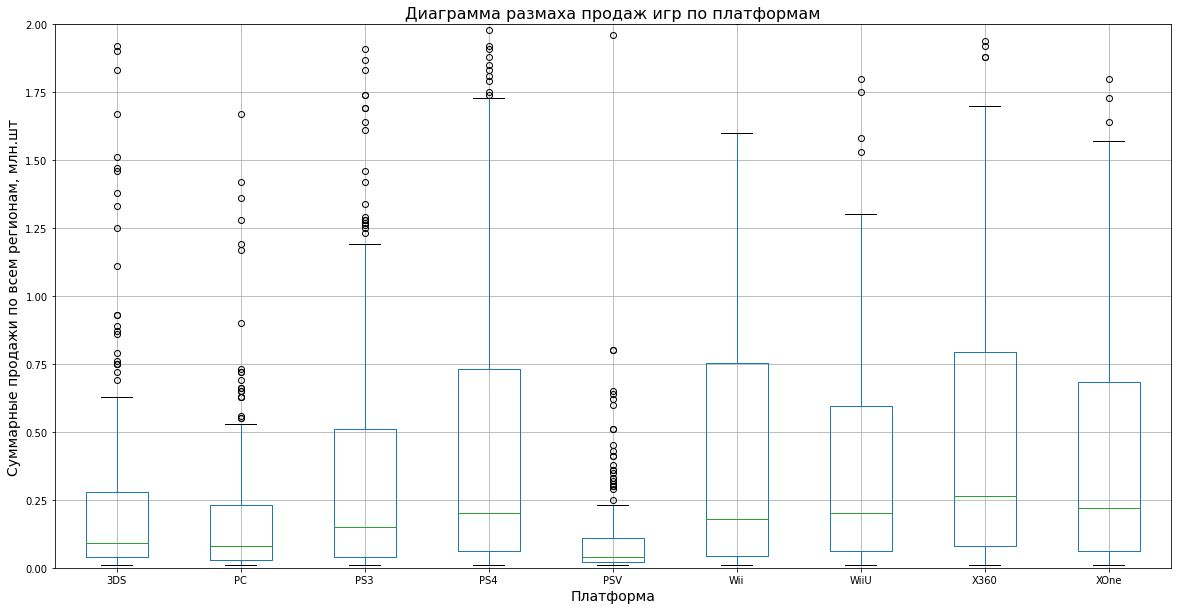

In [49]:
sales_platform_box=current_time.pivot_table(index='name', columns='platform', values='total_sales', aggfunc = 'sum') \
    .plot(kind = 'box', figsize=(20, 10), grid = True);
plt.ylim(0, 2)
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=14)
plt.xlabel('Платформа', size=14)
plt.title('Диаграмма размаха продаж игр по платформам', size=16);
plt.show()

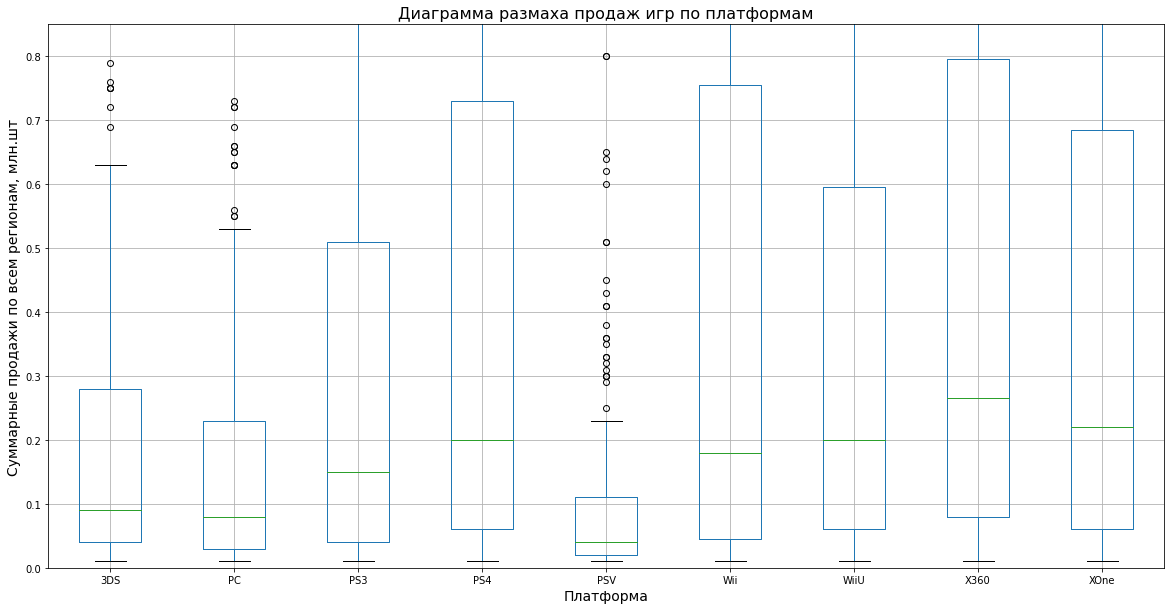

In [50]:
# масштабируем
sales_platform_box=current_time.pivot_table(index='name', columns='platform', values='total_sales', aggfunc = 'sum') \
    .plot(kind = 'box', figsize=(20, 10), grid = True);
plt.ylim(0, 0.85)
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=14)
plt.xlabel('Платформа', size=14)
plt.title('Диаграмма размаха продаж игр по платформам', size=16);
plt.show()

***Вывод:*** \
Платформы имеют совершенно разные кол-ва продаж копий игр за последнии 4 года - их МКР сильно отличаются друг от друга. Огромное количество выбросов. Медианное значение всей выборки в 120 тыс копий не совпадает с большинством медианных значений продаж на платформах по отдельности. У потенциально прибыльных платформ PS4 и XOne пределы нормальных значений не превышают 1.7 млн копий их медианные значений около 240 тыс.копий. Также достаточно широкий диазозон продаж у платформ X360 и Wii. Медианное значение продаж на платформе X360 больше всех - 260 тыс копий.

### Посмотреть, как влияют на продажи внутри одной популярной платформы отзывы пользователей и критиков. Построить диаграмму рассеяния и посчитать корреляцию между отзывами и продажами. Сформулировать выводы

In [51]:
pop_plat = current_time.query('platform == "PS4" and critic_score < 110 and user_score < 11')

Взяли самую популярую и продаваемую платформу - PS4. Убрали из данных замененные пропуски.

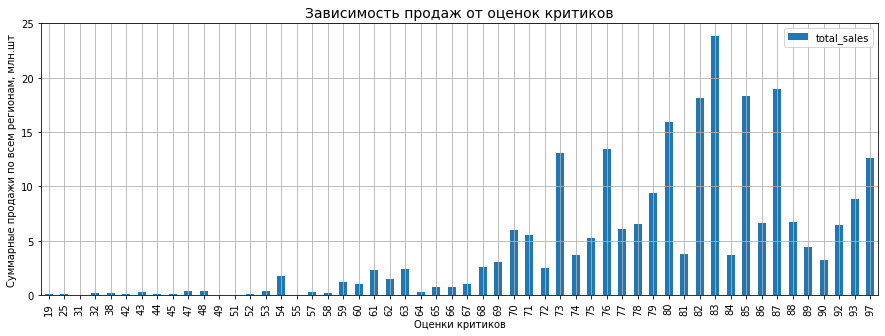

In [52]:
score_critic = pop_plat.pivot_table(index='critic_score', values='total_sales', aggfunc = 'sum')
score_critic.plot(kind='bar', grid=True, figsize=(15, 5));
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки критиков', size=10)
plt.title('Зависимость продаж от оценок критиков', size=14);
plt.show()

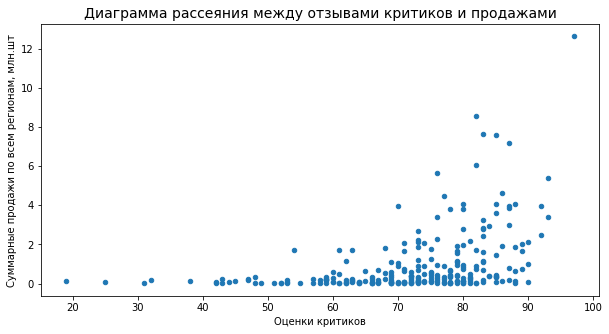

In [53]:
# диаграмма рассеяния между отзывами критиков и продажами
pop_plat.plot(kind='scatter', x='critic_score', y='total_sales', figsize=(10, 5))
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки критиков', size=10)
plt.title('Диаграмма рассеяния между отзывами критиков и продажами', size=14);
plt.show()

In [54]:
pop_plat['critic_score'].corr(pop_plat['total_sales']).round(2) # коэффициент корреляции

0.41

Коэффициент корреляции положительный, но слабый. На диаграмме рассеяния наблюдается отсутствие линейной связи - продажи лежат на одном уровне (около 250-500 тыс), независимо от оценки критиков, лишь на максимальных оценках налюдается появление больших продаж. Следовательно, оценки критиков несущесвенно коррелируют с кол-вом проданных игр.

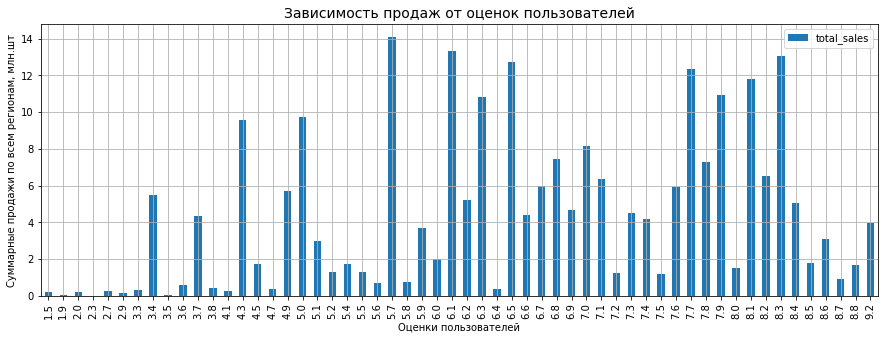

In [55]:
score_user = pop_plat.pivot_table(index='user_score', values='total_sales', aggfunc = 'sum')
score_user.plot(kind='bar', grid=True, figsize=(15, 5));
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки пользователей', size=10)
plt.title('Зависимость продаж от оценок пользователей', size=14);
plt.show()

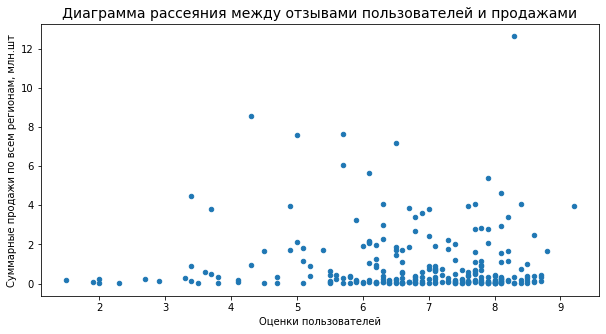

In [56]:
# диаграмма рассеяния между отзывами пользователей и продажами
pop_plat.plot(kind='scatter', x='user_score', y='total_sales', figsize=(10, 5))
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки пользователей', size=10)
plt.title('Диаграмма рассеяния между отзывами пользователей и продажами', size=14);
plt.show()

In [57]:
pop_plat['user_score'].corr(pop_plat['total_sales']).round(2) # коэффициент корреляции

-0.03

Коэффициент корреляции отрицательный и крайне слабый. Диаграмма рассеяния доказывает отсутствие связи между отзывами пользователей и продажами. Следовательно, оценки пользователей никак не коррелируют кол-во проданных игр.

***Вывод:*** \
Оценки пользователей корреляции с продажами не имеют. \
Оценки критиков демонстрируют прямую, средне-слабую корреляцию с продажами - меньше 0.5.

### Соотнести выводы с продажами игр на других платформах

In [58]:
# оценки пользователй умножили на 10 для кратности с оценками критиков
# чтобы показать оценки пользователей и критиков на одном графике 
current_time['user_score_new'] = current_time['user_score']*10
current_time['user_score_new'].astype('int')

/tmp/ipykernel_68/2966087035.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  current_time['user_score_new'] = current_time['user_score']*10


16        82
23        81
31       110
33       110
42        83
        ... 
16703    110
16707    110
16710    110
16712    110
16714    110
Name: user_score_new, Length: 2158, dtype: int64

In [59]:
ps_3_plat = current_time.query('platform == "PS3" and critic_score < 110 and user_score_new < 110')

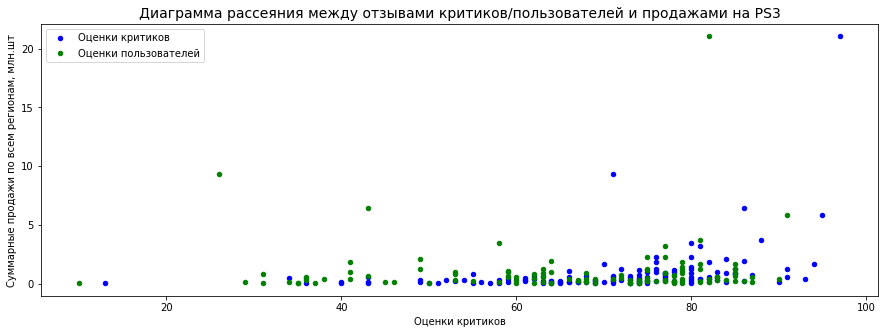

In [60]:
fig, ax = plt.subplots(figsize = (15,5))
ps_3_plat.plot(kind='scatter', x='critic_score', y='total_sales', color = 'blue', label = 'Оценки критиков', ax=ax)
ps_3_plat.plot(kind='scatter', x='user_score_new', y='total_sales', color = 'green', label = 'Оценки пользователей', ax=ax)
plt.legend()
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки критиков', size=10)
plt.title('Диаграмма рассеяния между отзывами критиков/пользователей и продажами на PS3', size=14);
plt.show()

In [61]:
print('Коэффициент корреляции между оценкой критиков и продажами на PS3', \
      ps_3_plat['critic_score'].corr(ps_3_plat['total_sales']).round(2))
print('Коэффициент корреляции между оценкой пользователей и продажами на PS3', \
      ps_3_plat['user_score_new'].corr(ps_3_plat['total_sales']).round(2))

Коэффициент корреляции между оценкой критиков и продажами на PS3 0.33
Коэффициент корреляции между оценкой пользователей и продажами на PS3 0.02


In [62]:
xone_plat = current_time.query('platform == "XOne" and critic_score < 110 and user_score_new < 110')

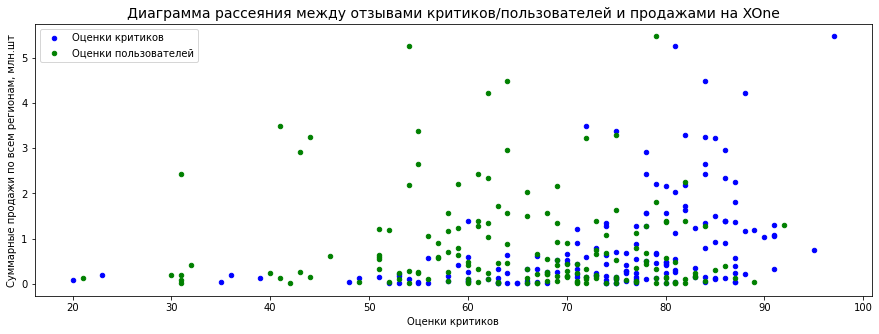

In [63]:
fig, ax = plt.subplots(figsize = (15,5))
xone_plat.plot(kind='scatter', x='critic_score', y='total_sales', color = 'blue', label = 'Оценки критиков', ax=ax)
xone_plat.plot(kind='scatter', x='user_score_new', y='total_sales', color = 'green', label = 'Оценки пользователей', ax=ax)
plt.legend()
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки критиков', size=10)
plt.title('Диаграмма рассеяния между отзывами критиков/пользователей и продажами на XOne', size=14);
plt.show()

In [64]:
print('Коэффициент корреляции между оценкой критиков и продажами на XOne', \
      xone_plat['critic_score'].corr(xone_plat['total_sales']).round(2))
print('Коэффициент корреляции между оценкой пользователей и продажами на XOne', \
      xone_plat['user_score_new'].corr(xone_plat['total_sales']).round(2))

Коэффициент корреляции между оценкой критиков и продажами на XOne 0.41
Коэффициент корреляции между оценкой пользователей и продажами на XOne -0.09


In [65]:
three_ds_plat = current_time.query('platform == "3DS" and critic_score < 110 and user_score_new < 110')

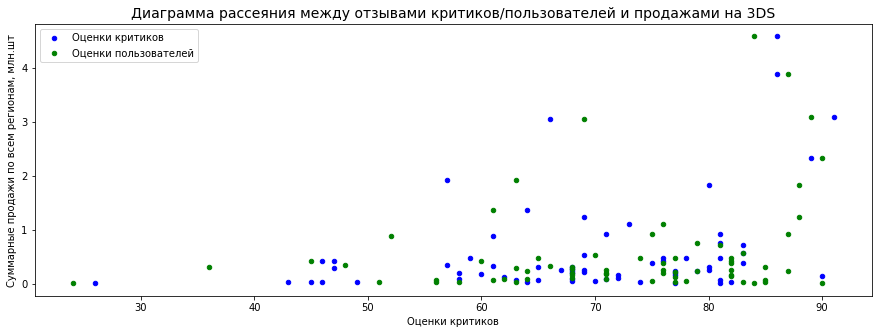

In [66]:
fig, ax = plt.subplots(figsize = (15,5))
three_ds_plat.plot(kind='scatter', x='critic_score', y='total_sales', color = 'blue', label = 'Оценки критиков', ax=ax)
three_ds_plat.plot(kind='scatter', x='user_score_new', y='total_sales', color = 'green', label = 'Оценки пользователей', ax=ax)
plt.legend()
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки критиков', size=10)
plt.title('Диаграмма рассеяния между отзывами критиков/пользователей и продажами на 3DS', size=14);
plt.show()

In [67]:
print('Коэффициент корреляции между оценкой критиков и продажами на 3DS', \
      three_ds_plat['critic_score'].corr(three_ds_plat['total_sales']).round(2))
print('Коэффициент корреляции между оценкой пользователей и продажами на 3DS', \
      three_ds_plat['user_score_new'].corr(three_ds_plat['total_sales']).round(2))

Коэффициент корреляции между оценкой критиков и продажами на 3DS 0.34
Коэффициент корреляции между оценкой пользователей и продажами на 3DS 0.27


In [68]:
x_360_plat = current_time.query('platform == "X360" and critic_score < 110 and user_score_new < 110')

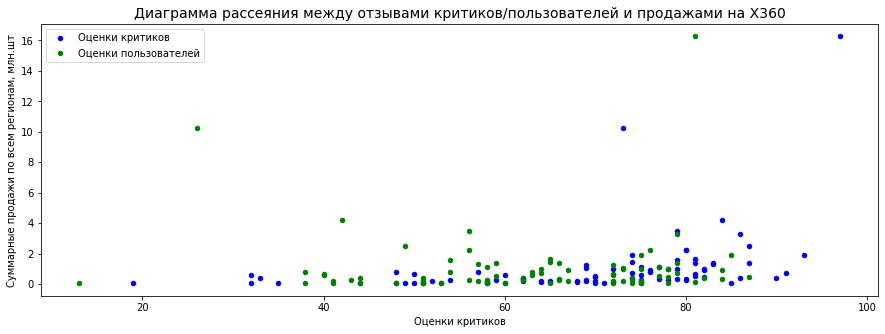

In [69]:
fig, ax = plt.subplots(figsize = (15,5))
x_360_plat.plot(kind='scatter', x='critic_score', y='total_sales', color = 'blue', label = 'Оценки критиков', ax=ax)
x_360_plat.plot(kind='scatter', x='user_score_new', y='total_sales', color = 'green', label = 'Оценки пользователей', ax=ax)
plt.legend()
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Оценки критиков', size=10)
plt.title('Диаграмма рассеяния между отзывами критиков/пользователей и продажами на X360', size=14);
plt.show()

In [70]:
print('Коэффициент корреляции между оценкой критиков и продажами на X360', \
      x_360_plat['critic_score'].corr(x_360_plat['total_sales']).round(2))
print('Коэффициент корреляции между оценкой пользователей и продажами на X360', \
      x_360_plat['user_score_new'].corr(x_360_plat['total_sales']).round(2))

Коэффициент корреляции между оценкой критиков и продажами на X360 0.35
Коэффициент корреляции между оценкой пользователей и продажами на X360 -0.01


In [71]:
all_plat = current_time.query('critic_score < 110 and user_score < 11 and platform != "PC" and \
    platform != "PSV" and platform != "WiiU"')
all_plat = all_plat.loc[:, ('platform', 'critic_score', 'user_score', 'total_sales')]
all_plat

,platform,critic_score,user_score,total_sales
16,PS3,97,8.2,21.05
23,X360,97,8.1,16.27
42,PS4,97,8.3,12.62
60,X360,73,2.6,10.24
69,PS3,71,2.6,9.36
...,...,...,...,...
16526,PS4,61,7.9,0.01
16530,PS4,51,5.5,0.01
16597,XOne,65,6.0,0.01
16630,XOne,63,8.2,0.01


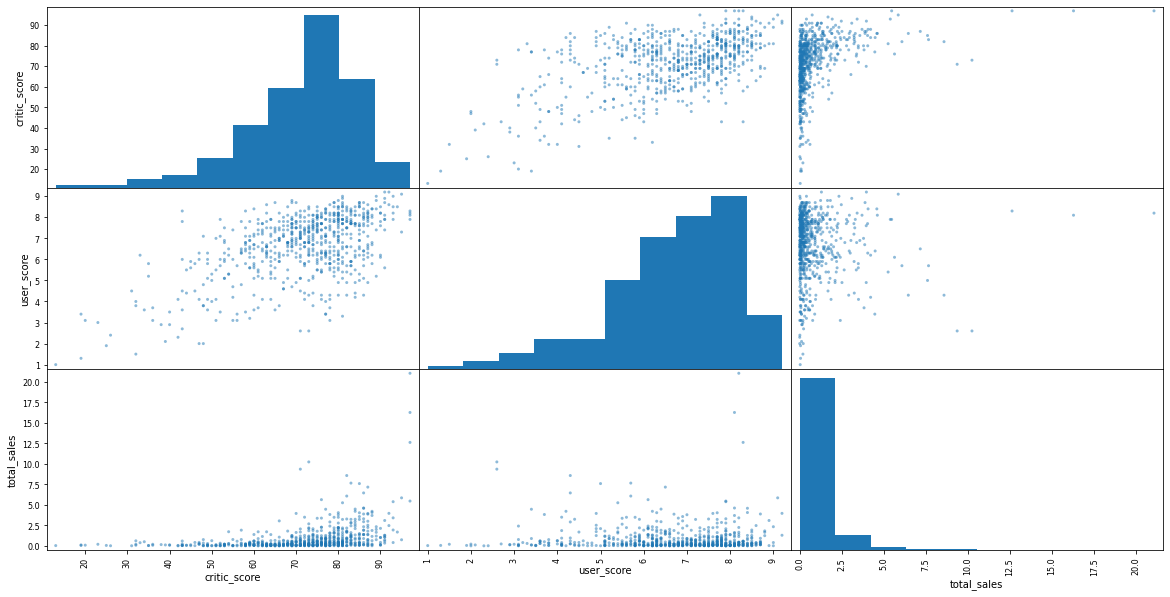

In [72]:
# общая картина зависимостей продаж от отзывов пользователей и критиков
pd.plotting.scatter_matrix(all_plat, figsize=(20, 10));

In [73]:
all_plat.corr()

,critic_score,user_score,total_sales
critic_score,1.000000,0.545927,0.357731
user_score,0.545927,1.000000,-0.013332
total_sales,0.357731,-0.013332,1.000000


In [74]:
score_critic_median=all_plat.groupby('platform').agg({'critic_score': ['median'], 'user_score': ['median']})
score_critic_median

,critic_score,user_score
,median,median
platform,,
3DS,69,7.50
PS3,73,7.25
PS4,74,7.00
X360,74,6.50
XOne,76,6.80


***Вывод:*** \
По всем платформам целиком ситуация одинаковая:
- коэффициент корреляции между оценкой критиков и продажами положительный, но слабый и нелинейный - от 0.33 до 0.41. 
- коэффициент корреляции между отзывами пользователей и продажами отрицательный и крайне слабый до -0.09. Оценки пользователей корреляции с продажами не имеют.

### Посмотреть на общее распределение игр по жанрам. Что можно сказать о самых прибыльных жанрах? Выделяются ли жанры с высокими и низкими продажами

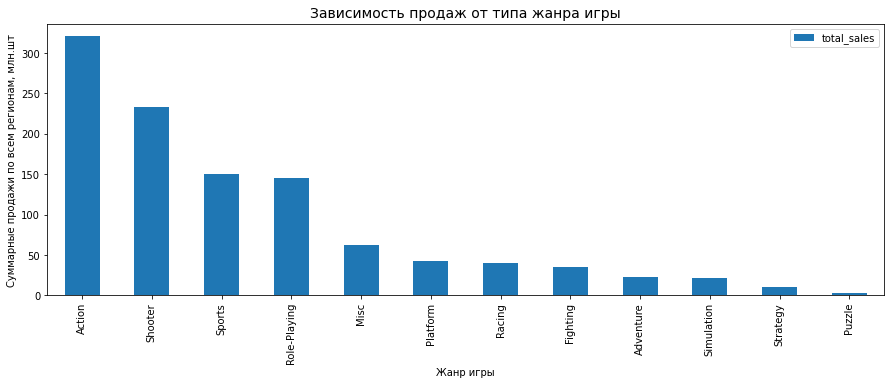

In [75]:
genre_sales = current_time.pivot_table(index='genre', values='total_sales', aggfunc='sum') \
    .sort_values('total_sales', ascending=False)
genre_sales.plot(kind='bar', y='total_sales', figsize=(15, 5))
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=10)
plt.xlabel('Жанр игры', size=10)
plt.title('Зависимость продаж от типа жанра игры', size=14);
plt.show()       


4 жанра лидируют по продажам: Action, Shooter, Spotrs, Role-Playing. Крайне маленькие продажи жанра Puzzle.

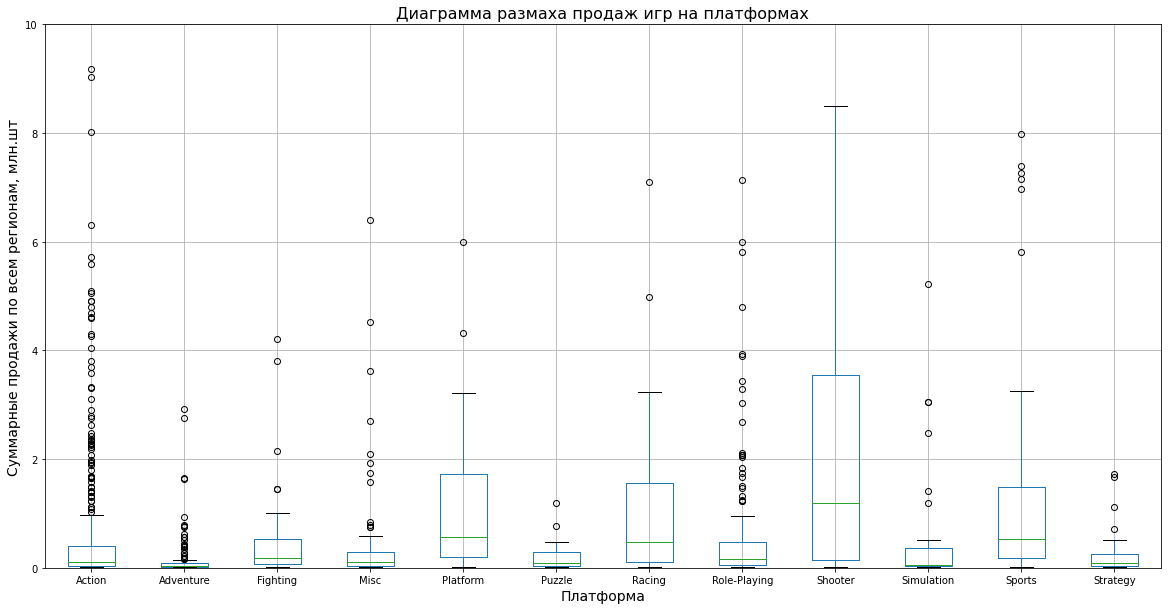

In [76]:
genre_sales_box=current_time.pivot_table(index='name', columns='genre', values='total_sales', aggfunc = 'sum') \
    .plot(kind = 'box', figsize=(20, 10), grid = True);
plt.ylim(0, 10)
plt.ylabel('Суммарные продажи по всем регионам, млн.шт', size=14)
plt.xlabel('Платформа', size=14)
plt.title('Диаграмма размаха продаж игр на платформах', size=16);
plt.show()

Самое большое медианное значение 1.2 млн и большой размах продаж до 8.5 млн копий имеет жанр Shooter. У остальных жанров медианное значение максимум доходит до 500 тыс. Второе место по стабильности продаж занимают платформы Spotrs, Platform и  Racing. 

In [77]:
genre_sales_median = current_time.groupby('genre')['total_sales'].median().sort_values(ascending=False)
genre_sales_median

genre
Shooter         0.450
Sports          0.250
Platform        0.225
Fighting        0.130
Role-Playing    0.120
Racing          0.120
Misc            0.115
Action          0.110
Simulation      0.100
Strategy        0.080
Puzzle          0.060
Adventure       0.030
Name: total_sales, dtype: float64

Самые высокие медианные значения принадлежат жанрам Shooter, Spotrs, Platform.

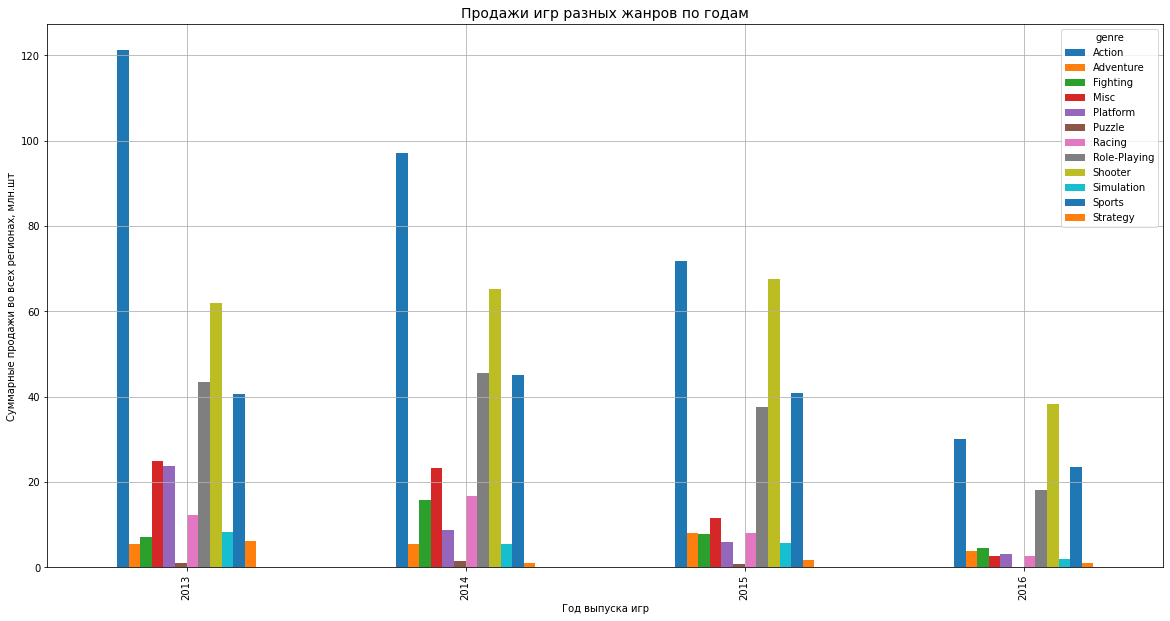

In [78]:
# продажи игр разных жанров с наибольшими суммарными продажами по годам
genre_sales_year = current_time.pivot_table(index=['year_of_release'], values='total_sales', columns='genre', aggfunc='sum') \
    .sort_values(by='year_of_release').plot(kind='bar', grid=True, figsize=(20, 10))
plt.ylabel('Суммарные продажи во всех регионах, млн.шт', size=10)
plt.xlabel('Год выпуска игр', size=10)
plt.title('Продажи игр разных жанров по годам', size=14)
plt.show()    

Жанр Action - самый продаваемый, линейно падает со 120 млн до 30 млн за 4 года (к концу 2016). \
Жанр Shooter имеет самые высоки продажи в 2015 году - около 70 млн копий. К 2016 продажи упали до 40 млн копий. \
Жанр Spotrs имеет самые высоки продажи в 2014 году - около 45 млн копий. К 2016 продажи упали до 25 млн копий. \
Жанр Role-Playing имеет самые высоки продажи в 2014 году - около 45 млн копий. К 2016 продажи менее 20 млн копий. \

К концу 2016 года жанры Misc и Platform крайне малы, по-сравнению с продажами этих жанров в 2013 году.

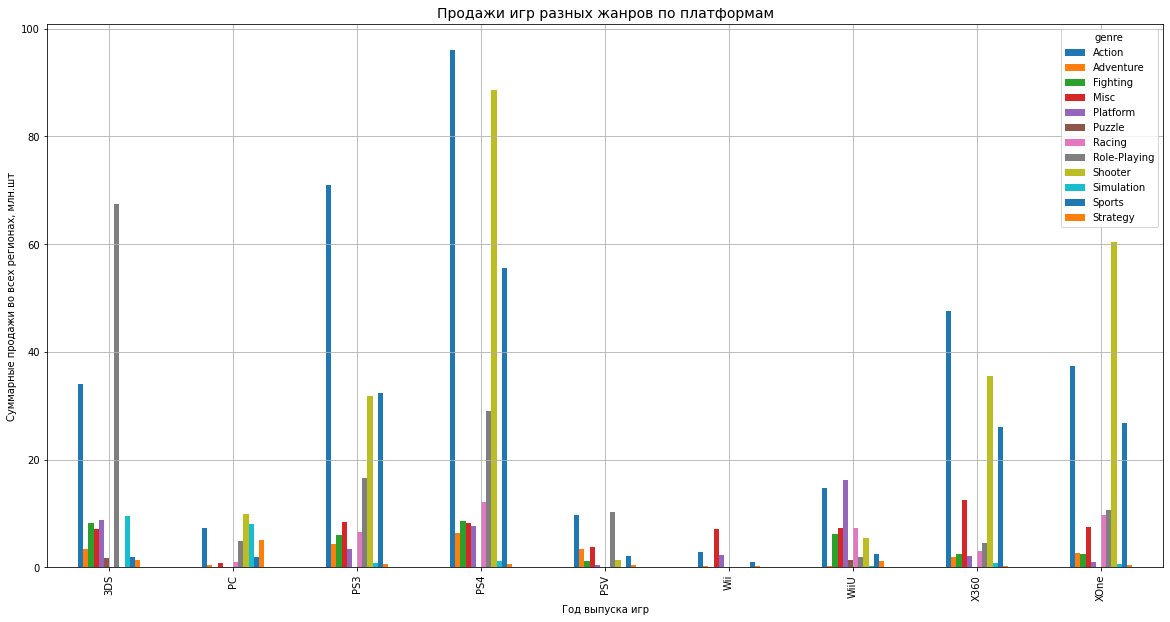

In [79]:
# продажи игр на платформах с наибольшими суммарными продажами по годам
genre_sales_plat = current_time.pivot_table(index=['platform'], values='total_sales', columns='genre', aggfunc='sum') \
    .sort_values(by='platform').plot(kind='bar', grid=True, figsize=(20, 10))
plt.ylabel('Суммарные продажи во всех регионах, млн.шт', size=10)
plt.xlabel('Год выпуска игр', size=10)
plt.title('Продажи игр разных жанров по платформам', size=14)
plt.show() 

Платформа с самыми высокими суммарными продажами PS4 имеет аналогичную (как и общий показатель) хронологию лидерства жанров по продажам - Action, Shooter, Spotrs, Role-Playing. \
На платформе XOne лидирует жанр Shooter, далее Action и Spotrs, а Role-Playing значительно упал в продажах. \
На платформе X360 - Action, Shooter, Spotrs, а Role-Playing аналогично значительно упал в продажах. \
Жанр Role-Playing имеет популярность на платформе 3DS. \
На платформе PS3 лидирует жанр Action, на одном уровне Shooter и Spotrs, ниже Role-Playing.

***Вывод:*** \
За последние четыре года наиболее востребованными жанрами являются Action, Shooter, Sports. Медианные значения и МКР больше всего у жанров Shooter и Sports , что говорит о стабильности и прибыльности. \
Жанр Action самую большую популярность имел в 2013 году, далее продажи пожают, но все же остается в топе лидеров. Этот жанр популярнее всего на платформах  PS4, PS3, X360. \
Жанр Shooter самую большую популярность имел в 2015 году и хорошо продаваем на платформах PS4, XOne, X360 и PS3. \
Жанр Spotrs самую большую популярность имел в 2014 году на платформах PS4, X360, XOne, 3DS и PS3. 

2016 год показывает спад по всем жанрам, но так как есть вероятность, что данные за 2016 год могут быть неполными, то ориентируемся на предыдущий год(или 3 года) и следим за 2016 и обстановкой в мире. \
Рекомендация ознакомиться с информацией, что и какие события в мире могут влиять или влияют на продажи/на популярность тех или иных жанров. 

## Шаг 4. Составить портрет пользователя каждого региона

Определите для пользователя каждого региона (NA, EU, JP): 
- самые популярные платформы (топ-5). Опишите различия в долях продаж
- самые популярные жанры (топ-5). Поясните разницу
- влияет ли рейтинг ESRB на продажи в отдельном регионе

### Определить для пользователя каждого региона (NA, EU, JP) самые популярные платформы (топ-5). Описать различия в долях продаж

In [80]:
sales_platform_na = current_time.pivot_table(index='platform', values='na_sales', aggfunc='sum') \
    .sort_values(by='na_sales', ascending=False).reset_index()
# начиная с 5 строчки замена названий платформ на 'другие'
sales_platform_na.loc[5:,'platform'] = 'Other'
# для 5 строчек считаем продажи 
sales_platform_na.loc[5,'na_sales'] =  sales_platform_na.loc[5:,'na_sales'].sum().round(2)
# выводим первые 5 строк
sales_platform_na = sales_platform_na.iloc[:6]
sales_platform_na

,platform,na_sales
0,PS4,108.74
1,XOne,93.12
2,X360,81.66
3,PS3,63.50
4,3DS,38.20
5,Other,51.92


Топ 5 популярных платформ в Северной Америке: 'PS4', 'XOne', 'X360', 'PS3', '3DS'

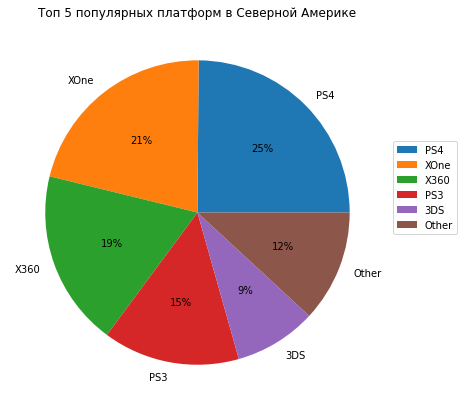

In [81]:
labels = sales_platform_na['platform']
sales_platform_na.plot(kind='pie', y='na_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='', labels=labels,  title='Топ 5 популярных платформ в Северной Америке')
plt.legend(bbox_to_anchor=(1, 0.7));

In [82]:
total_na_sales = sales_platform_na['na_sales'].sum()
print('Суммарные продажи в Северной Америке', total_na_sales.round(2), 'млн копий')

Суммарные продажи в Северной Америке 437.14 млн копий


In [83]:
sum_sales = current_time['total_sales'].sum()
print('Суммарные продажи во всех регионах', sum_sales.round(2), 'млн копий')

Суммарные продажи во всех регионах 1085.65 млн копий


In [84]:
rate_na = total_na_sales/sum_sales 
print('Доля продаж Северной Америки относительно рынка {:.0%}'.format(rate_na))

Доля продаж Северной Америки относительно рынка 40%


In [85]:
sales_platform_eu = current_time.pivot_table(index='platform', values='eu_sales', aggfunc='sum') \
    .sort_values(by='eu_sales', ascending=False).reset_index()
# начиная с 5 строчки замена названий платформ на 'другие'
sales_platform_eu.loc[5:,'platform'] = 'Other'
# для 5 строчек считаем продажи 
sales_platform_eu.loc[5,'eu_sales'] =  sales_platform_eu.loc[5:,'eu_sales'].sum().round(2)
# выводим первые 5 строк
sales_platform_eu = sales_platform_eu.iloc[:6]
sales_platform_eu

,platform,eu_sales
0,PS4,141.09
1,PS3,67.81
2,XOne,51.59
3,X360,42.52
4,3DS,30.96
5,Other,57.24


Топ 5 популярных платформ в Европе: 'PS4', 'PS3', 'XOne', 'X360', '3DS'

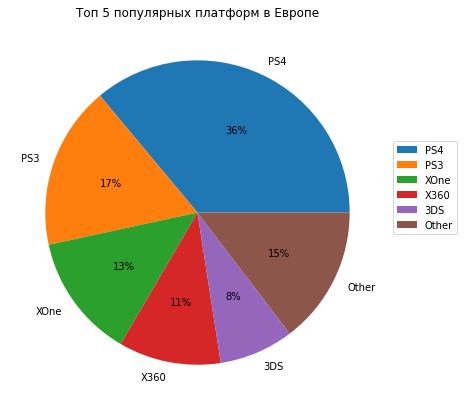

In [86]:
labels = sales_platform_eu['platform']
sales_platform_eu.plot(kind='pie', y='eu_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='', labels=labels,  title='Топ 5 популярных платформ в Европе')
plt.legend(bbox_to_anchor=(1, 0.7));

In [87]:
total_eu_sales = sales_platform_eu['eu_sales'].sum()
print('Суммарные продажи в Европе', total_eu_sales.round(2), 'млн копий')

Суммарные продажи в Европе 391.21 млн копий


In [88]:
rate_eu = total_eu_sales/sum_sales 
print('Доля продаж Европы относительно рынка {:.0%}'.format(rate_eu))

Доля продаж Европы относительно рынка 36%


In [89]:
sales_platform_jp = current_time.pivot_table(index='platform', values='jp_sales', aggfunc='sum') \
    .sort_values(by='jp_sales', ascending=False).reset_index()
# начиная с 5 строчки замена названий платформ на 'другие'
sales_platform_jp.loc[5:,'platform'] = 'Other'
# для 5 строчек считаем продажи 
sales_platform_jp.loc[5,'jp_sales'] =  sales_platform_jp.loc[5:,'jp_sales'].sum().round(2)
# выводим первые 5 строк
sales_platform_jp = sales_platform_jp.iloc[:6]
sales_platform_jp

,platform,jp_sales
0,3DS,67.81
1,PS3,23.35
2,PSV,18.59
3,PS4,15.96
4,WiiU,10.88
5,Other,0.90


Топ 5 популярных платформ в Японии: '3DS', 'PS3', 'PSV', 'PS4', 'WiiU'

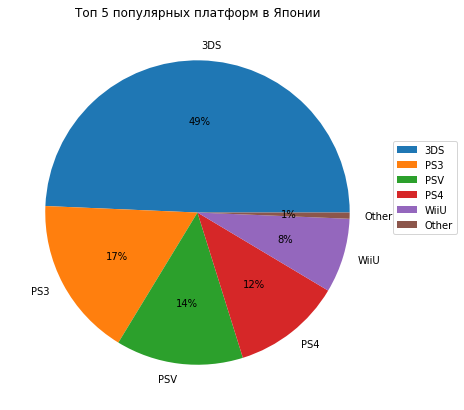

In [90]:
labels = sales_platform_jp['platform']
sales_platform_jp.plot(kind='pie', y='jp_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='', labels=labels,  title='Топ 5 популярных платформ в Японии')
plt.legend(bbox_to_anchor=(1, 0.7));

In [91]:
total_jp_sales = sales_platform_jp['jp_sales'].sum()
print('Суммарные продажи в Японии', total_jp_sales.round(2), 'млн копий')

Суммарные продажи в Японии 137.49 млн копий


In [92]:
rate_jp = total_jp_sales/sum_sales 
print('Доля продаж Японии относительно рынка {:.0%}'.format(rate_jp))

Доля продаж Японии относительно рынка 13%


***Вывод:*** \
Северная Америка составляет 40% продаж игр от всего рынка. Европа - 36%, Япония - 13%, другие страны - 11%. \
Популярность платформы PS3 распределена равномерно по регионам. 
В Северной Америке топ 5 платформ - PS4, XOne, X360, PS3, 3DS, где платформа PS4 занимает четверть их рынка.
В Европе топ 5 платформ - PS4, PS3, XOne, X360, 3DS, где платформа PS4 занимает 36% их рынка. 
В Японии топ 5 платформ - 3DS, PS3, PSV, PS4, WiiU, где платформа PS4 занимает 12% их рынка, а лидирует 3DS - 49%. Других платформ в Японии практически нет.

### Определить для пользователя каждого региона (NA, EU, JP) самые популярные жанры (топ-5). Пояснить разницу

In [93]:
sales_genre_na = current_time.pivot_table(index='genre', values='na_sales', aggfunc='sum') \
    .sort_values(by='na_sales', ascending=False).reset_index()
# начиная с 5 строчки замена названий жанров на 'другие'
sales_genre_na.loc[5:,'genre'] = 'Other'
# для 5 строчек считаем продажи 
sales_genre_na.loc[5,'na_sales'] =  sales_genre_na.loc[5:,'na_sales'].sum().round(2)
# выводим первые 5 строк
sales_genre_na = sales_genre_na.iloc[:6]
sales_genre_na

,genre,na_sales
0,Action,125.83
1,Shooter,109.74
2,Sports,65.27
3,Role-Playing,46.40
4,Misc,27.46
5,Other,62.44


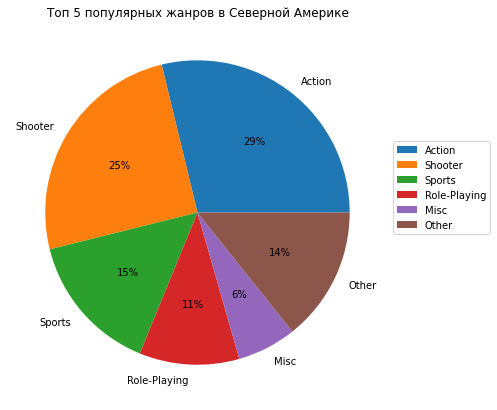

In [94]:
labels = sales_genre_na['genre']
sales_genre_na.plot(kind='pie', y='na_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='', labels=labels,  title='Топ 5 популярных жанров в Северной Америке')
plt.legend(bbox_to_anchor=(1, 0.7));

In [95]:
sales_genre_eu = current_time.pivot_table(index='genre', values='eu_sales', aggfunc='sum') \
    .sort_values(by='eu_sales', ascending=False).reset_index()
# начиная с 5 строчки замена названий жанров на 'другие'
sales_genre_eu.loc[5:,'genre'] = 'Other'
# для 5 строчек считаем продажи 
sales_genre_eu.loc[5,'eu_sales'] =  sales_genre_eu.loc[5:,'eu_sales'].sum().round(2)
# выводим первые 5 строк
sales_genre_eu = sales_genre_eu.iloc[:6]
sales_genre_eu

,genre,eu_sales
0,Action,117.87
1,Shooter,87.86
2,Sports,60.34
3,Role-Playing,36.97
4,Racing,20.19
5,Other,67.98


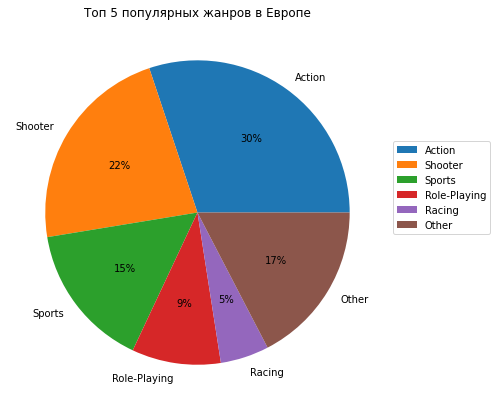

In [96]:
labels = sales_genre_eu['genre']
sales_genre_eu.plot(kind='pie', y='eu_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='', labels=labels,  title='Топ 5 популярных жанров в Европе')
plt.legend(bbox_to_anchor=(1, 0.7));

In [97]:
sales_genre_jp = current_time.pivot_table(index='genre', values='jp_sales', aggfunc='sum') \
    .sort_values(by='jp_sales', ascending=False).reset_index()
# начиная с 5 строчки замена названий жанров на 'другие'
sales_genre_jp.loc[5:,'genre'] = 'Other'
# для 5 строчек считаем продажи 
sales_genre_jp.loc[5,'jp_sales'] =  sales_genre_jp.loc[5:,'jp_sales'].sum().round(2)
# выводим первые 5 строк
sales_genre_jp = sales_genre_jp.iloc[:6]
sales_genre_jp

,genre,jp_sales
0,Role-Playing,50.01
1,Action,39.65
2,Misc,9.03
3,Fighting,7.63
4,Shooter,6.61
5,Other,24.56


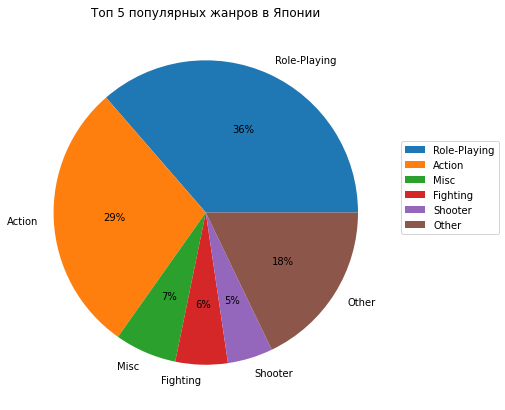

In [98]:
labels = sales_genre_jp['genre']
sales_genre_jp.plot(kind='pie', y='jp_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='', labels=labels,  title='Топ 5 популярных жанров в Японии')
plt.legend(bbox_to_anchor=(1, 0.7));

***Вывод:*** \
В Северной Америке топ 5 жанров - Action, Shooter, Sports, Role-Playing, Misc, где Action занимает 29% их рынка, а Shooter -25%. \
В Европе топ 5 платформ аналогичны Северной Амереке, только последнее место занимает жанр Racing. Action занимает 30% их рынка, а Shooter - 22%. \
В Японии топ 5 платформ - Role-Playing, Action, Misc, Fighting, Shooter, где Action занимает 29% их рынка, а Shooter -5%. Лидирует жанр Role-Playing - 36%.

Жанр Action одинаково популярен в разных странах. В Европе в отличии от Японии и СА в топе жанров присутствует Racing и отсутствует Misc, а в Японии в отличии от Европы и СА присутствует жанр Fighting.

### Определить для пользователя каждого региона (NA, EU, JP) влияет ли рейтинг ESRB на продажи в отдельном регионе

In [99]:
sales_rating_na = current_time.pivot_table(index='rating', values='na_sales', aggfunc='sum') \
    .sort_values(by='na_sales', ascending=False)

In [100]:
sales_rating_na['rate']=sales_rating_na['na_sales']/total_na_sales
sales_rating_na.round(2)

,na_sales,rate
rating,,
M,165.21,0.38
unknown,89.18,0.20
E,78.94,0.18
E10+,54.02,0.12
T,49.79,0.11


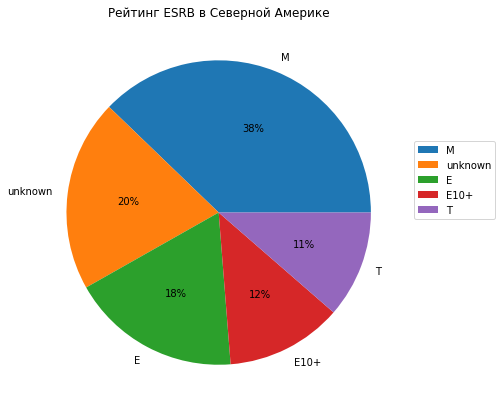

In [101]:
sales_rating_na.plot(kind='pie', y='na_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='',  title='Рейтинг ESRB в Северной Америке')
plt.legend(bbox_to_anchor=(1, 0.7));

In [102]:
sales_rating_eu = current_time.pivot_table(index='rating', values='eu_sales', aggfunc='sum') \
    .sort_values(by='eu_sales', ascending=False)

In [103]:
sales_rating_eu['rate']=sales_rating_eu['eu_sales']/total_eu_sales
sales_rating_eu.round(2)

,eu_sales,rate
rating,,
M,145.32,0.37
E,82.80,0.21
unknown,78.61,0.20
E10+,42.53,0.11
T,41.95,0.11


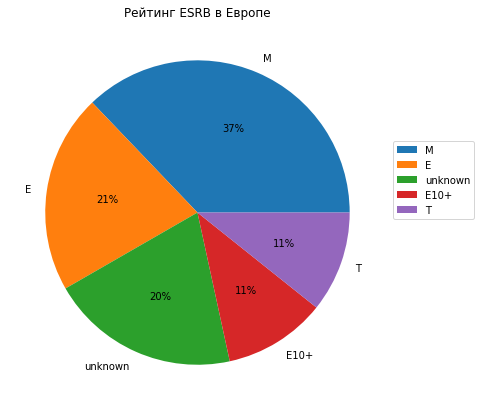

In [104]:
sales_rating_eu.plot(kind='pie', y='eu_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='',  title='Рейтинг ESRB в Европе')
plt.legend(bbox_to_anchor=(1, 0.7));

In [105]:
sales_rating_jp = current_time.pivot_table(index='rating', values='jp_sales', aggfunc='sum') \
    .sort_values(by='jp_sales', ascending=False)

In [106]:
sales_rating_jp['rate']=sales_rating_jp['jp_sales']/total_jp_sales
sales_rating_jp.round(2)

,jp_sales,rate
rating,,
unknown,82.05,0.60
T,20.44,0.15
E,15.00,0.11
M,14.11,0.10
E10+,5.89,0.04


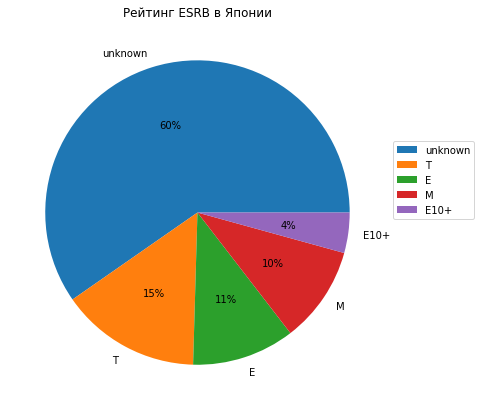

In [107]:
sales_rating_jp.plot(kind='pie', y='jp_sales', autopct='%1.0f%%', \
                       figsize=(7,7), label='',  title='Рейтинг ESRB в Японии')
plt.legend(bbox_to_anchor=(1, 0.7));

***Вывод:*** \
ESRB не является юридически обязательной для выпуска игры, но без присвоенного рейтинга большинство крупных магазинов просто откажутся её продавать. Также компании не обязаны предоставлять игру на определение рейтинга до начала официальных продаж, так как её содержимое может значительно измениться в ходе разработки. Поэтому отсутствие рейтинга связано, либо с доработкой игры, либо с нелегальными продажами, либо в другой стране своя система оценки игр. \
Во всех трех регионах присутствуют лишь 4 вида рейтинга - E, E10+, M, T и доля неизвестного рейтинга - unknown. \
В Северной Америке и Европе преобладают игры для взрослых от 17 лет(M) - до 38% и для всех от 6 лет(E) до 21%. Отстутствие данных о категории до 20%. \
В Японии в основной массе категории игр неизвестны - 60%, далее 15% принадлежит категории - подросткам от 13(Т). \
Таким образом, можно сделать вывод, что влияние рейтинга на продажи в Северной Америке и Европе почти одинаково, отстутствие о рейтинге на рынке только 20%. А вот в Японии рейтинг ESRB особого влияния не оказывает, так как большая доля игр с неизвестным рейтингом. Возможно у них другая/своя система оценки игр.

Портрет пользователей по регионам: \
Самый продаваемый регион - Северная Америка - занимает 40% рынка. Европа - 36%, Япония - 13%, другие страны - 11%. \
Предпочтения в жанрах и платформах в Северной Америке и Европе очень схожи между собой - лидирует платформа PS4, а жанры Action и Shooter. Другие платформа занимают до 15% рынка в регионах. Игры рейтинга 'M' и 'E'. \
В Японии другая картина: 
- фигурируют в целом 5 платформ, лишь 1 % рынка в Японии принадлежит другим платформам 
- лидирует платформа 3DS, а жанр Role-Playing 
- в основном игры неизвестного рейтинга ESRB и 'Т' 

Жанр Action и платформа PS3 одинаково популярены в разных странах. 

## Шаг 5. Проверить гипотезы

Задать самостоятельно пороговое значение alpha.
Пояснить:
- как вы сформулировали нулевую и альтернативную гипотезы
- какой критерий применили для проверки гипотез и почему

### Средние пользовательские рейтинги платформ Xbox One и PC одинаковые

Нулевая и альтернативная гипотезы:

Н0: Средние пользовательские рейтинги платформ Xbox One и PC равны

Н1: Средние пользовательские рейтинги платформ Xbox One и PC не равны

In [108]:
x_one = current_time.query('platform == "XOne" and user_score < 11')
display(x_one['user_score'].describe())
pc = current_time.query('platform == "PC" and user_score < 11')
display(pc['user_score'].describe())

count    182.000000
mean       6.521429
std        1.380941
min        1.600000
25%        5.800000
50%        6.800000
75%        7.500000
max        9.200000
Name: user_score, dtype: float64

count    155.000000
mean       6.269677
std        1.742381
min        1.400000
25%        5.300000
50%        6.800000
75%        7.600000
max        9.300000
Name: user_score, dtype: float64

Из описательной статистики видим, что выборки разного размера и значения медиан одинаковые, среднии чуть отличаются, а стандартные отклонения тоже чуть отличаются. Общепринятые пороговые значения критерия - 5% и 1%. Установим критерий проверки 5%.

In [109]:
# задаём уровень значимости
alpha = 0.05

# проводим ttest для двух выборок, в качестве альтернативной используем двустороннюю гипотезу
results = st.ttest_ind(x_one['user_score'], pc['user_score'], equal_var=False)

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 0.14759594013430463
Не получилось отвергнуть нулевую гипотезу


***Вывод:*** \
В данном случае p-value достаточно велико - выше уровня значимости. Средний пользовательский рейтинг платформ Xbox One и PC неодинаков, с вероятностью в почти 15%, такое или большее различие можно получить случайно. Это явно слишком большая вероятность, чтобы делать вывод о значимом различии между средними оценками пользователей на разных платформах.  

Потенциально прибыльная платформа XOne предположительно имеет в среднем такие же пользовательские оценки, как и платформа PC, которая не показывает грандиозных продаж, значит пользовательские оценки не влияют на продажи.

### Средние пользовательские рейтинги жанров Action  и Sports разные

Нулевая и альтернативная гипотезы:

Н0: Средние пользовательские рейтинги жанров Action и Sports равны

Н1: Средние пользовательские рейтинги жанров Action и Sports не равны

In [110]:
action = current_time.query('genre == "Action" and user_score < 11')
display(action['user_score'].describe())
sports = current_time.query('genre == "Sports" and user_score < 11')
display(sports['user_score'].describe())

count    388.000000
mean       6.842784
std        1.327847
min        2.000000
25%        6.300000
50%        7.100000
75%        7.800000
max        9.100000
Name: user_score, dtype: float64

count    159.000000
mean       5.249686
std        1.783038
min        0.200000
25%        4.100000
50%        5.500000
75%        6.500000
max        8.800000
Name: user_score, dtype: float64

Из описательной статистики видим, что выборки разного размера и значения медиан, среднии и стандартные отклонения разные. Общепринятые пороговые значения критерия - 5% и 1%. Установим критерий проверки 5%.

In [111]:
# задаём уровень значимости
alpha = 0.05

# проводим ttest для двух выборок, в качестве альтернативной используем двустороннюю гипотезу
results = st.ttest_ind(action['user_score'], sports['user_score'], equal_var=False)

print(f'p-value: {results.pvalue}')

# проверяем p-value
if results.pvalue < alpha:
    print('Отвергаем нулевую гипотезу')
else:
    print('Не получилось отвергнуть нулевую гипотезу')

p-value: 2.419141451747253e-20
Отвергаем нулевую гипотезу


***Вывод:*** \
p-value крайне маленькая - близка к 0, т.е результаты крайне маловероятные (при условии, что гипотеза верна), значит среднии значения пользовательских рейтингиов жанров Action и Sports значимо отличаются друг от друга.

Нулевая гипотеза всего формулируется так, что средняя одной одной выборки равна конкретному числу или среднии двух выборок равны между собой. Альтернативные гипотезы формулируется так, что средняя этой одной выборки больше или меньше конкретного числа или не равна конкретному числу, а для двух выборок альтернатиные гипотезы: среднее значение первой выборки больше или меньше второй или среднии выборки не равны друг другу.
В пункет 5.1 - "средние пользовательские рейтинги платформ Xbox One и PC одинаковые" - это 2 выборки, следовательно, нулевая гипотеза формулируется так, что среднии двух выборок равны между собой, а альтернативная - среднии выборки не равны друг другу.
В пункет 5.2 -"средние пользовательские рейтинги жанров Action и Sports разные" - это тоже 2 выборки и необходимо проверить равны они или нет и неважно в какую сторону, поэтому берем альтернативную двустороннюю гипотезу - среднии выборки не равны друг другу, а нулевая - среднии двух выборок равны между собой.

## Шаг 6. Общий вывод

В целях прогнозирования продаж на 2017 год и выявления потенциально успешного продукта на игровом рынке были проанализированы исторические данные о продажах игр, оценки пользователей и экспертов, жанры и платформы интернет-магазина «Стримчик» и установлены некоторые закономерности. 

На этапе предобработки датасет был приведен к нормам стиля, были удалены дубликаты, часть пропусков удалены (менее 2%), другая часть пропусков заменена значениями «заглушками», чтобы не потерять информацию, а также изменены типи данных по некоторым столбцам для работы с числовыми данными.

Датасет предоставлял информацию за 1980-2016 года. До начала 1992 года данные малоинформативны, поэтому рассматривали период 1992-2016 включительно. В результате исследования выделены 6 лидирующих по продажам платформ - 'PS2', 'X360', 'PS3', 'Wii', 'DS', 'PS'. Их срок жизни в среднем 11 лет, а пик по продажам достигается в среднем за 4 года. Следовательно, для прогнозирования продаж на 2017 год определили актуальный период – последние 4 года, начиная с 2013 по 2016 включительно. 

Выделены 5 лидирующих по продажам платформ за актуальный период - PS4, PS3, XOne, 3DS, X360, из которых 2 платформы находятся в состоянии роста - PS4, XOne - потенциально прибыльные платформы, а также PS4 по продажам уходит с большим отрывом. У платформ PS4, XOne и X360 пределы нормальных значений не превышают 1.7 млн копий, а вот медианное значение выше всех у X360, что говорит о прибыльности. Так же стоит отметить, что все платформы к 2016 году идут на уменьшение продаж.

За последние четыре года наиболее востребованными жанрами являются Action, Shooter, Sports. Именно такая хронология лидерства жанров на платформах PS4 и X360. А вот на XOne на первом месте Shooter. Медианные значения и МКР больше всего у жанров Shooter и Sports, что говорит о прибыльности этих жанров. 2016 год показывает спад по всем жанрам, но так как есть вероятность, что данные за 2016 год могут быть неполными, то ориентируемся на предыдущий год (или 3 года) и следим за 2016 и обстановкой в мире. 

Северная Америка составляет 40% продаж игр от всего рынка. Европа - 36%, Япония - 13%, другие страны - 11%. \
Предпочтения в жанрах и платформах в Северной Америке и Европе очень схожи между собой: в топе одинаковые платформы - PS4, XOne, X360, PS3, 3DS, лишь меняется порядок, из которых лидирует у них платформа PS4, а по жанрам лидируют Action и Shooter – вместе занимают чуть больше 50% рынка. Другие платформа занимают до 15% рынка в регионах. Игры рейтинга 'M' и 'E' – от 17 и 6 лет соответственно и игры неизвестного рейтинга 20%. \
В Японии фигурируют в целом 5 платформ - 3DS, PS3, PSV, PS4, WiiU, лишь 1 % рынка в Японии принадлежит другим платформам. Лидирует платформа 3DS - 49%, а жанр Role-Playing. Платформа PS4 на предпоследнем месте, занимает лишь 12% рынка. В основном игры неизвестного рейтинга ESRB и 'Т' – от 13 лет.

Установили важные инсайты:
- оценки пользователей корреляции с продажами не имеют; 
- оценки критиков демонстрируют прямую, средне-слабую корреляцию с продажами - меньше 0.5;
- влияние рейтинга, предпочтения в жанрах и платформах в Северной Америке и Европе очень схожи, в отличии от Японии;
- в Японии 60% рынка не используют рейтинг ESRB, скорее всего у них другая система;
- во всех регионах: присутствуют лишь 4 вида рейтинга - 'E','E10+', 'M', 'T' и доля неизвестного рейтинга – unknown, где рейтинг 'T' во всех регионах около 12%, жанр Action одинаково популярен – около 30%; платформа PS3 распределена равномерно по регионам – по 17%;

Исходя из жизненного цикла, медианных значений прибыльности и популярности жанров можно сделать следующие прогнозы на 2017 год и выводы: 

Для Европы и Северной Америки: \
   - стоит сделать ставку на новые, зародившиеся в 2013 году, платформы PS4, XOne;
   - возможно небольшую прибыль принесет платформа X360, ее медианные значения продаж высокие, но стоит отметить ее возраст – 6 лет;
   - жанры Shooter и Sports имеют высокое медианное значение и широкий МКР, а значит прибыльные;

- платформе XOne хорошую прибыль приносит жанр Shooter;
- в Европе в отличии от Японии и Северной Америке в топе жанров присутствует Racing и отсутствует Misc, а в Японии в отличии от Европы и СА присутствует жанр Fighting; 
- в Европе и Северной Америке рейтинги 'M' и 'E' занимают 58%, а в Японии 60% рынка игр с неизвестным рейтингом;

Для Японии: 
- популярны старые платформы и их ораниченное кол-во, ставка на 3DS и еще PS3;
- жанры Role-Playing и Action;

Гипотезу о том, что средние пользовательские рейтинги платформ XOne и PC равны не получилось отвергуть. Потенциально прибыльная платформа XOne предположительно имеет в среднем такие же пользовательские оценки, как и платформа PC, которая не показывает грандиозных продаж, значит пользовательские оценки не влияют на продажи.
Гипотезу о том, что средние пользовательские рейтинги жанров Action и Sports равны - отвергли, на основании крейне маленькой вероятности о значимом различии между средними оценками. Значит среднии значения пользовательских рейтингиов жанров Action и Sports значимо отличаются друг от друга.

Рекомендация ознакомиться с информацией, что и какие события в мире могут влиять или влияют на продажи/на популярность тех или иных жанров. Следить за рынком - появлением новых платформ, которые дают хорошую прибыль. Изучить подробнее индустрию Японии, так как их показатели отличаются от других регионов. 
